# 02  STM youtube_sent (nivel sentenca, pipeline independente)

Config e treinamento separados de 01_stm_youtube_doc.ipynb. Ver
docs/superpowers/specs/2026-09-20-stm-youtube-sent-design.md.

## 1. Setup e imports

In [1]:
# ── path fix: resolve _helpers.py e data/ de qualquer subdiretório ──
import sys as _sys, os as _os
from pathlib import Path as _P
_here = _P().resolve()
_nb_dir = _here if (_here / '_helpers.py').exists() else _here.parent
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))
_os.chdir(_nb_dir)          # '../data/...' paths ficam corretos
del _here, _nb_dir, _P, _sys, _os
# ─────────────────────────────────────────────────────────────────────
# Cell 1 — Imports
import sys, os, json, time, ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from _helpers import load_params, get_corpus_config, get_seed, load_corpus
from _helpers import lemmatize_corpus
from _helpers import (
    prepare_stm_input, grid_search_k_stm, grid_search_stm_hparams, train_stm,
    qualitative_report,
)
from _helpers import name_all_topics, name_topic
from _helpers import (
    compute_coherence_cv, compute_exclusivity, compute_exclusivity_ctfidf, compute_diversity,
    compute_topic_diversity, compute_frex_score, compute_stability,
    export_results, export_topics_for_eval,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


D:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2  Carrega params do params.yaml
CORPUS_ID = "youtube_sent"
LANG = "en"

params = load_params()
_, cfg = get_corpus_config(params, CORPUS_ID)
seed = get_seed(params)
TEXT_COL = cfg["text_column"]
ID_COL = cfg["post_id_column"]
PREV_FORMULA = cfg.get("stm_prevalence_formula", "") or ""
MIN_TOKENS = int(cfg.get("stm_min_tokens_per_doc", 0) or 0)
assert PREV_FORMULA, "stm_prevalence_formula vazia no params.yaml  defina a formula do corpus"

print(f"corpus_id = {CORPUS_ID}")
print(f"text_column = {TEXT_COL}")
print(f"post_id_column = {ID_COL}")
print(f"language = {LANG}")
print(f"seed = {seed}")
print(f"covariates = {cfg.get('covariates', [])}")
print(f"prevalence_formula = {PREV_FORMULA}")
print(f"min_tokens_per_doc = {MIN_TOKENS}")

corpus_id = youtube_sent
text_column = sentence
post_id_column = sent_id
language = en
seed = 42
covariates = ['product_category']
prevalence_formula = ~ product_category
min_tokens_per_doc = 5


## 2. Corpus de sentencas

In [3]:
# Cell 3  Carrega corpus_sentencas.csv (run mais recente de 02-sentences)
from _helpers import resolve_latest_dir

_corpus_dir = resolve_latest_dir(
    "../../02-sentences/data/output/youtube_sent",
    contains="corpus_sentencas.csv",
)
CORPUS_VERSION = _corpus_dir.name
print(f"Versao do corpus: {CORPUS_VERSION}")

df = pd.read_csv(_corpus_dir / "corpus_sentencas.csv", encoding="utf-8")
print(f"Total de sentencas carregadas: {len(df):,}")
print(f"Colunas: {list(df.columns)}")
df.head(3)

  versão resolvida: youtube_sent_20260920_141442/ (latest)
Versao do corpus: youtube_sent_20260920_141442


Total de sentencas carregadas: 130,016
Colunas: ['sent_id', 'post_id', 'sent_idx', 'sentence', 'context', 'message_raw', 'message_punctuated', 'punctuation_restored', 'n_words', 'is_fragment', 'is_dup_exact', 'upload_date', 'year', 'channel', 'source', 'product_category']


,sent_id,post_id,sent_idx,sentence,context,message_raw,message_punctuated,punctuation_restored,n_words,is_fragment,is_dup_exact,upload_date,year,channel,source,product_category
0,WmhKCq0vfjE_0,WmhKCq0vfjE,0,Hey what's up guys MkBHD here and every once i...,Hey what's up guys MkBHD here and every once i...,Hey what's up guys MkBHD here and every once i...,Hey what's up guys MkBHD here and every once i...,False,52,False,False,2016-02-17,2016,Marques Brownlee,whisper,headphone
1,WmhKCq0vfjE_1,WmhKCq0vfjE,1,I promise I didn't pick them up just because I...,Hey what's up guys MkBHD here and every once i...,Hey what's up guys MkBHD here and every once i...,Hey what's up guys MkBHD here and every once i...,False,17,False,False,2016-02-17,2016,Marques Brownlee,whisper,headphone
2,WmhKCq0vfjE_2,WmhKCq0vfjE,2,I picked them up because they already kind of ...,I promise I didn't pick them up just because I...,Hey what's up guys MkBHD here and every once i...,Hey what's up guys MkBHD here and every once i...,False,13,False,False,2016-02-17,2016,Marques Brownlee,whisper,headphone


## 3. Limpeza pre-STM (nao sobrescreve corpus_sentencas.csv)

In [4]:
# Cell 4  Filtros pre-STM: fragmento, duplicata exata, covariavel NA, tamanho minimo
_n0 = len(df)
df = df[(~df["is_fragment"]) & (~df["is_dup_exact"])].reset_index(drop=True)
print(f"Removidas por fragmento/duplicata: {_n0 - len(df)} (restam {len(df)})")

_cov_cols = cfg.get("covariates", [])
_n0 = len(df)
df = df.dropna(subset=_cov_cols).reset_index(drop=True)
print(f"Removidas por covariavel NA ({_cov_cols}): {_n0 - len(df)} (restam {len(df)})")

_n0 = len(df)
df = df[df["n_words"] >= MIN_TOKENS].reset_index(drop=True)
print(f"Removidas por < {MIN_TOKENS} palavras: {_n0 - len(df)} (restam {len(df)})")

docs = df[TEXT_COL].astype(str).tolist()
post_ids = df[ID_COL].astype(str).tolist()
print()
print(f"Total sentencas apos limpeza: {len(docs):,}")
df["product_category"].value_counts()

Removidas por fragmento/duplicata: 13905 (restam 116111)
Removidas por covariavel NA (['product_category']): 0 (restam 116111)
Removidas por < 5 palavras: 0 (restam 116111)

Total sentencas apos limpeza: 116,111


product_category
laptop       65666
phone        30911
other         5535
tablet        3395
headphone     3249
watch         2315
desktop       1228
camera        1221
console       1189
monitor        845
vr             557
Name: count, dtype: int64

## 4. Config local do STM e lematizacao

In [5]:
# Cell 5  STM_CFG local: overrides de no_below/no_above SO deste corpus,
# sem tocar em params["stm"] (que segue valendo para youtube_doc)
STM_CFG = {
    **params["stm"],
    "no_below": cfg["stm_no_below"],
    "no_above": cfg["stm_no_above"],
}
print(f"STM_CFG: no_below={STM_CFG['no_below']} no_above={STM_CFG['no_above']} "
      f"max_em_its={STM_CFG.get('max_em_its')} timeout_sec={STM_CFG.get('timeout_sec')}")

print("Lematizando (single-process spaCy en_core_web_sm)...")
t0 = time.time()
tokenized, dictionary = lemmatize_corpus(
    docs, LANG, {"stm": STM_CFG}, model_key="stm",
    extra_stopwords=cfg.get("stopwords_emojis"),
)
print(f"  done em {time.time()-t0:.0f}s")
print(f"  vocab final: {len(dictionary):,} palavras (apos filter_extremes no_below={STM_CFG['no_below']})")

n_tokens_lemma = [len(t) for t in tokenized]
print(f"  avg tokens/sentenca apos lemmatize: {np.mean(n_tokens_lemma):.1f}")

STM_CFG: no_below=20 no_above=0.5 max_em_its=300 timeout_sec=21600
Lematizando (single-process spaCy en_core_web_sm)...


  done em 251s
  vocab final: 2,760 palavras (apos filter_extremes no_below=20)
  avg tokens/sentenca apos lemmatize: 6.5


## 5. Amostra estratificada para os grids (por product_category)

In [6]:
# Cell 6  Amostra estratificada por product_category, seed=42, ~stm_grid_sample_size
from gensim.corpora import Dictionary

TARGET_SAMPLE = int(cfg.get("stm_grid_sample_size", 25000))
_frac = min(1.0, TARGET_SAMPLE / len(df))
print(f"Amostrando fracao {_frac:.4f} de cada product_category (alvo={TARGET_SAMPLE:,}, corpus={len(df):,})")

_sample_idx = (
    df.groupby("product_category", group_keys=False)
    .apply(lambda g: g.sample(frac=_frac, random_state=seed))
    .index
)
df_sample = df.loc[_sample_idx].reset_index(drop=True)
tokenized_sample = [tokenized[i] for i in _sample_idx]

dictionary_sample = Dictionary(tokenized_sample)
dictionary_sample.filter_extremes(no_below=STM_CFG["no_below"], no_above=STM_CFG["no_above"])

print(f"Amostra: {len(df_sample):,} sentencas | vocab amostra: {len(dictionary_sample):,}")

print()
print("Proporcao por categoria (corpus completo vs amostra):")
_prop_full = df["product_category"].value_counts(normalize=True).rename("full")
_prop_sample = df_sample["product_category"].value_counts(normalize=True).rename("sample")
print(pd.concat([_prop_full, _prop_sample], axis=1).round(4))

Amostrando fracao 0.2153 de cada product_category (alvo=25,000, corpus=116,111)


C:\Users\Douglas_Notebook\AppData\Local\Temp\ipykernel_31512\2320874402.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(frac=_frac, random_state=seed))


Amostra: 25,000 sentencas | vocab amostra: 1,208

Proporcao por categoria (corpus completo vs amostra):
                    full  sample
product_category                
laptop            0.5655  0.5656
phone             0.2662  0.2662
other             0.0477  0.0477
tablet            0.0292  0.0292
headphone         0.0280  0.0280
watch             0.0199  0.0199
desktop           0.0106  0.0106
camera            0.0105  0.0105
console           0.0102  0.0102
monitor           0.0073  0.0073
vr                0.0048  0.0048


## 6. Input do STM: amostra (grids) e corpus completo (treino final)

In [7]:
# Cell 7  stm_df (corpus completo, treino final) e stm_df_sample (grids)
stm_df = prepare_stm_input(df, tokenized, covariates=cfg.get("covariates", []))
stm_df_sample = prepare_stm_input(df_sample, tokenized_sample, covariates=cfg.get("covariates", []))

print(f"stm_df (completo):  {len(stm_df):,} linhas | colunas: {stm_df.columns.tolist()}")
print(f"stm_df_sample:      {len(stm_df_sample):,} linhas | colunas: {stm_df_sample.columns.tolist()}")
stm_df.head(3)

stm_df (completo):  116,111 linhas | colunas: ['text', 'post_id', 'product_category']
stm_df_sample:      25,000 linhas | colunas: ['text', 'post_id', 'product_category']


,text,post_id,product_category
0,hey mkbhd get switch exactly headphone try new...,WmhKCq0vfjE,headphone
1,promise pick read black definitely help,WmhKCq0vfjE,headphone
2,pick great reputation,WmhKCq0vfjE,headphone


## 7. Selecao de K (grid na amostra estratificada)

In [8]:
# Cell 8  Grid search K na AMOSTRA (carrega resultado pre-computado se existir)
from _helpers import make_run_output_dir
BASE_OUTPUT_DIR = Path(f"../data/output/{CORPUS_ID}/stm")
BASE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = make_run_output_dir(BASE_OUTPUT_DIR, CORPUS_ID)
out_dir = str(OUTPUT_DIR)

m_path = f"{BASE_OUTPUT_DIR}/stm_metrics.csv"
diag_path = f"{BASE_OUTPUT_DIR}/stm_grid_k_diagnostics.csv"

if os.path.exists(m_path):
    m = pd.read_csv(m_path)
    scores = ast.literal_eval(m.iloc[0]["k_grid_scores"])
    scores = {int(k): float(v) for k, v in scores.items()}
    diag_df = pd.read_csv(diag_path) if os.path.exists(diag_path) else pd.DataFrame()
    print(f"Carregado grid pre-computado de {m_path}")
elif os.path.exists(diag_path):
    diag_df = pd.read_csv(diag_path)
    scores = {int(k): float(v) for k, v in zip(diag_df["k"], diag_df["cv"])}
    print(f"Grid K reconstruido do cache de diagnosticos ({diag_path})")
elif cfg.get("stm_best_k"):
    scores, diag_df = {}, pd.DataFrame()
    print(f"Grid K desligado  stm_best_k={cfg['stm_best_k']} pinado no params.yaml")
else:
    K_RANGE = cfg["stm_k_range"]
    print(f"Rodando grid K em {K_RANGE} na amostra ({len(stm_df_sample):,} sentencas, 1 fit STM/R por K, split heldout)...")
    scores, diag_df = grid_search_k_stm(stm_df_sample, tokenized_sample, dictionary_sample, K_RANGE, PREV_FORMULA, STM_CFG, work_dir=out_dir, seed=seed, top_n=params["evaluation"]["top_n_keywords"])
    diag_df.to_csv(diag_path, index=False)
    print("Done.")

scores

Rodando grid K em [10, 15, 20, 25, 30, 35, 40] na amostra (25,000 sentencas, 1 fit STM/R por K, split heldout)...


[stm] cmd: Rscript D:\Documentos\youtube_metadata_collection\03-topic-modeling\scripts\run_stm.R --mode grid_k --input ..\data\output\youtube_sent\stm\youtube_sent_20260920_225112\stm_input.csv --output_dir ..\data\output\youtube_sent\stm\youtube_sent_20260920_225112 --seed 42 --no_below 20 --no_above 0.5 --max_em_its 300 --prevalence ~ product_category --k_grid 10,15,20,25,30,35,40 --top_n 10


[run_stm] mode=grid_k docs=24579 vocab=1208 removed=421 prevalence='~ product_category'
[grid_k] K=10 heldout=-6.2740 disp=6.853 semcoh=-171.71 excl=9.68 its=20 (55s)
[grid_k] K=15 heldout=-6.2469 disp=6.172 semcoh=-179.07 excl=9.80 its=22 (69s)
[grid_k] K=20 heldout=-6.2323 disp=6.010 semcoh=-189.18 excl=9.85 its=27 (102s)
[grid_k] K=25 heldout=-6.2090 disp=6.798 semcoh=-199.90 excl=9.87 its=132 (529s)
[grid_k] K=30 heldout=-6.1979 disp=6.576 semcoh=-212.62 excl=9.90 its=68 (314s)
[grid_k] K=35 heldout=-6.1820 disp=6.707 semcoh=-222.68 excl=9.91 its=73 (379s)
[grid_k] K=40 heldout=-6.1697 disp=7.154 semcoh=-229.11 excl=9.92 its=101 (593s)
[run_stm] done



  K=10: C_v=0.5284


  K=15: C_v=0.5442


...

  K=25: C_v=0.5077


  K=30: C_v=0.4599


  K=35: C_v=0.4496


  K=40: C_v=0.4303
Done.


{10: 0.5283566631840687,
 15: 0.54417398457376,
 20: 0.5243456897746662,
 25: 0.5077175940328866,
 30: 0.459879412751759,
 35: 0.44958238891178826,
 40: 0.4302976465004432}

Salvo: ..\data\output\youtube_sent\stm\stm_grid_k_diagnostics.png


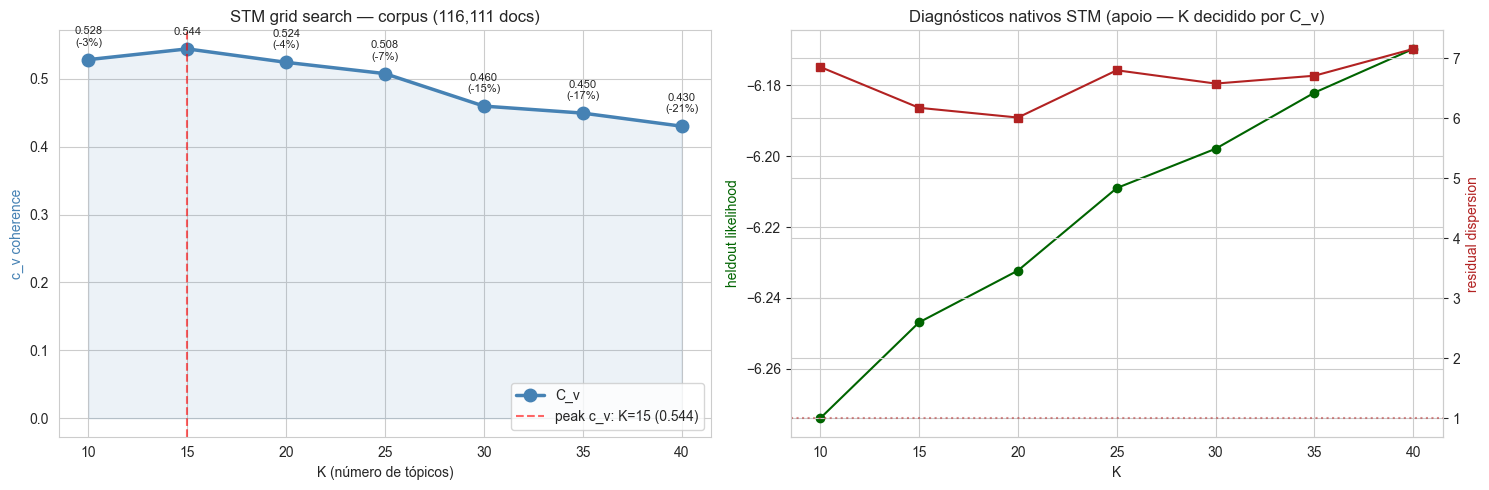


Peak: K=15 (c_v=0.5442)
 k       cv  heldout_likelihood  residual_dispersion  semantic_coherence  exclusivity_stm  diversity  iterations  elapsed_sec
10 0.528357           -6.274025             6.853158         -171.707827         9.684668   0.990000          20    55.339727
15 0.544174           -6.246931             6.172374         -179.073958         9.804027   0.986667          22    68.560550
20 0.524346           -6.232296             6.010077         -189.175281         9.850027   0.995000          27   101.665158
25 0.507718           -6.208985             6.797780         -199.903399         9.874677   0.996000         132   529.062781
30 0.459879           -6.197880             6.576049         -212.618162         9.900656   0.986667          68   313.724447
35 0.449582           -6.182031             6.706864         -222.679413         9.912434   0.982857          73   379.196363
40 0.430298           -6.169669             7.154091         -229.106197         9.918798   0

In [9]:
# Cell 9 — C_v vs K + diagnósticos nativos do STM (heldout / resíduos)
if not scores:
    print("Grid K desligado (stm_best_k pinado) e sem cache — nada a plotar.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    ks = sorted(scores)
    vs = [scores[k] for k in ks]

    ax = axes[0]
    ax.plot(ks, vs, marker="o", linewidth=2.5, markersize=9, color="steelblue", label="C_v")
    ax.fill_between(ks, vs, alpha=0.1, color="steelblue")
    peak_k = max(scores, key=scores.get)
    ax.axvline(peak_k, color="red", linestyle="--", alpha=0.6, label=f"peak c_v: K={peak_k} ({scores[peak_k]:.3f})")
    for k, v in zip(ks, vs):
        delta = (v - scores[peak_k]) / scores[peak_k] * 100
        label = f"{v:.3f}" if k == peak_k else f"{v:.3f}\n({delta:+.0f}%)"
        ax.annotate(label, (k, v), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8)
    ax.set_xlabel("K (número de tópicos)"); ax.set_ylabel("c_v coherence", color="steelblue")
    ax.set_title(f"STM grid search — corpus ({len(docs):,} docs)")
    ax.legend(loc="lower right")

    ax2 = axes[1]
    if not diag_df.empty:
        ax2.plot(diag_df["k"], diag_df["heldout_likelihood"], marker="o", color="darkgreen", label="heldout likelihood")
        ax2.set_xlabel("K"); ax2.set_ylabel("heldout likelihood", color="darkgreen")
        ax2b = ax2.twinx()
        ax2b.plot(diag_df["k"], diag_df["residual_dispersion"], marker="s", color="firebrick", label="residual dispersion")
        ax2b.set_ylabel("residual dispersion", color="firebrick")
        ax2b.axhline(1.0, color="firebrick", linestyle=":", alpha=0.5)
        ax2.set_title("Diagnósticos nativos STM (apoio — K decidido por C_v)")
    else:
        ax2.text(0.5, 0.5, "diagnostics não disponíveis\n(grid carregado de cache antigo)", ha="center", va="center")
        ax2.axis("off")
    plt.tight_layout()
    plt.savefig(BASE_OUTPUT_DIR / "stm_grid_k_diagnostics.png", dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Salvo: {BASE_OUTPUT_DIR / 'stm_grid_k_diagnostics.png'}")
    plt.show()

    print(f"\nPeak: K={peak_k} (c_v={scores[peak_k]:.4f})")
    if not diag_df.empty:
        print(diag_df.to_string(index=False))


Salvo: ..\data\output\youtube_sent\stm\stm_grid_semcoh_exclus.png


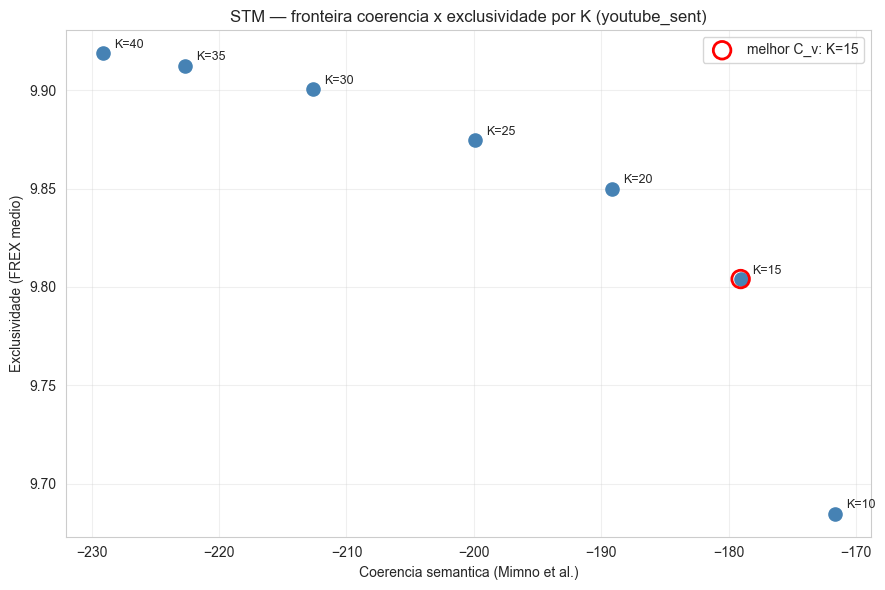

In [10]:
# Scatter semantic coherence x exclusivity por K (Roberts et al. — selecao de modelo STM)
_diag_csv = BASE_OUTPUT_DIR / "stm_grid_k_diagnostics.csv"
if _diag_csv.exists():
    _d = pd.read_csv(_diag_csv)
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(_d["semantic_coherence"], _d["exclusivity_stm"], s=90, color="steelblue", zorder=3)
    for _, r in _d.iterrows():
        ax.annotate(f"K={int(r['k'])}", (r["semantic_coherence"], r["exclusivity_stm"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=9)
    _best = _d.loc[_d["cv"].idxmax()]
    ax.scatter([_best["semantic_coherence"]], [_best["exclusivity_stm"]], s=160,
               facecolors="none", edgecolors="red", linewidths=2, zorder=4,
               label=f"melhor C_v: K={int(_best['k'])}")
    ax.set_xlabel("Coerencia semantica (Mimno et al.)")
    ax.set_ylabel("Exclusividade (FREX medio)")
    ax.set_title(f"STM — fronteira coerencia x exclusividade por K ({CORPUS_ID})")
    ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout()
    plt.savefig(BASE_OUTPUT_DIR / "stm_grid_semcoh_exclus.png", dpi=150, bbox_inches="tight", facecolor="white")
    print(f"Salvo: {BASE_OUTPUT_DIR / 'stm_grid_semcoh_exclus.png'}")
    plt.show()
else:
    print("Sem stm_grid_k_diagnostics.csv — scatter pulado")


## 8. Grid sigma x gamma (amostra, K fixo) + treino final (corpus completo)

In [11]:
# Cell 12  Grid sigma.prior x gamma.prior na AMOSTRA; treino final no corpus completo.
_pin_k = cfg.get("stm_best_k")
BEST_K = int(_pin_k) if _pin_k else max(scores, key=scores.get)
print(f"BEST_K {'pinado no params.yaml' if _pin_k else 'automatico (peak C_v na amostra)'}: {BEST_K}")

_shp_cache = f"{BASE_OUTPUT_DIR}/stm_sigma_gamma_grid.csv"
_sigma_grid = params["evaluation"].get("stm_sigma_prior_grid", [0, 0.3, 0.5, 0.7])
_gamma_grid = params["evaluation"].get("stm_gamma_prior_grid", ["Pooled", "L1"])
_pin_sigma, _pin_gamma = cfg.get("stm_sigma_prior"), cfg.get("stm_gamma_prior")
if _pin_sigma is not None and _pin_gamma:
    shp_df = pd.DataFrame()
    best_sigma, best_gamma = float(_pin_sigma), str(_pin_gamma)
    print(f"Grid sigma/gamma desligado  pinado: sigma={best_sigma}, gamma={best_gamma!r}")
elif os.path.exists(_shp_cache):
    shp_df = pd.read_csv(_shp_cache)
    best_sigma = float(shp_df.iloc[0]["sigma_prior"])
    best_gamma = str(shp_df.iloc[0]["gamma_prior"])
    print(f"Grid sigma/gamma carregado do cache ({_shp_cache}).")
else:
    print(f"Grid sigma ({len(_sigma_grid)}) x gamma ({len(_gamma_grid)}) na amostra ({len(stm_df_sample):,} sentencas)...")
    t0 = time.time()
    shp_df, best_sigma, best_gamma = grid_search_stm_hparams(stm_df_sample, tokenized_sample, dictionary_sample, BEST_K, PREV_FORMULA, STM_CFG, work_dir=out_dir, sigma_grid=_sigma_grid, gamma_grid=_gamma_grid, seed=seed, top_n=params["evaluation"]["top_n_keywords"])
    shp_df.to_csv(_shp_cache, index=False)
    print(f"  done em {time.time()-t0:.0f}s")

if not shp_df.empty:
    print(shp_df.to_string(index=False))
print(f"best_sigma={best_sigma!r}  best_gamma={best_gamma!r}")
print(f"Treinando STM final K={BEST_K}, sigma={best_sigma!r}, gamma={best_gamma!r} NO CORPUS COMPLETO ({len(stm_df):,} sentencas, Spectral, deterministico)...")
t0 = time.time()
keywords, keywords_frex, theta, beta_df, effects, stm_meta = train_stm(stm_df, BEST_K, PREV_FORMULA, STM_CFG, work_dir=out_dir, sigma_prior=best_sigma, gamma_prior=best_gamma, seed=seed, top_n=params["evaluation"]["top_n_keywords"])
print(f"  done em {time.time()-t0:.0f}s ({stm_meta['iterations']} iteracoes EM)")

_removed = set(stm_meta.get("docs_removed", []))
if _removed:
    _keep = [i for i in range(len(docs)) if i not in _removed]
    docs = [docs[i] for i in _keep]
    post_ids = [post_ids[i] for i in _keep]
    df = df.iloc[_keep].reset_index(drop=True)
    tokenized = [tokenized[i] for i in _keep]
    print(f"  {len(_removed)} sentencas removidas pelo prepDocuments do R (realinhadas)")
assert theta.shape == (len(docs), BEST_K), (theta.shape, len(docs))
topics_keywords = keywords
dominant = theta.argmax(axis=1).tolist()
full = theta.tolist()
theta_arr = theta
top_n = params["evaluation"]["top_n_keywords"]
for tid in sorted(topics_keywords):
    print(f"  T{tid:2d}: {topics_keywords[tid]}")
    print(f"        FREX: {keywords_frex[tid]}")

BEST_K automatico (peak C_v na amostra): 15
Grid sigma (4) x gamma (2) na amostra (25,000 sentencas)...
[stm] cmd: Rscript D:\Documentos\youtube_metadata_collection\03-topic-modeling\scripts\run_stm.R --mode grid_hparams --input ..\data\output\youtube_sent\stm\youtube_sent_20260920_225112\stm_input.csv --output_dir ..\data\output\youtube_sent\stm\youtube_sent_20260920_225112 --seed 42 --no_below 20 --no_above 0.5 --max_em_its 300 --prevalence ~ product_category --k 15 --sigma_grid 0,0.3,0.5,0.7 --gamma_grid Pooled,L1 --top_n 10


[run_stm] mode=grid_hparams docs=24579 vocab=1208 removed=421 prevalence='~ product_category'
[grid_hparams] sigma=0.00 gamma=Pooled its=29 (91s)
[grid_hparams] sigma=0.00 gamma=L1 its=29 (150s)
[grid_hparams] sigma=0.30 gamma=Pooled its=28 (79s)
[grid_hparams] sigma=0.30 gamma=L1 its=28 (121s)
[grid_hparams] sigma=0.50 gamma=Pooled its=28 (78s)
[grid_hparams] sigma=0.50 gamma=L1 its=28 (114s)
[grid_hparams] sigma=0.70 gamma=Pooled its=27 (75s)
[grid_hparams] sigma=0.70 gamma=L1 its=27 (110s)
[run_stm] done



  done em 829s
 sigma_prior gamma_prior       cv          bound  iterations  elapsed_sec
         0.7          L1 0.538397 -872643.619385          27   109.524342
         0.3          L1 0.538144 -872530.989766          28   121.302389
         0.7      Pooled 0.536699 -872587.155915          27    74.552367
         0.0      Pooled 0.536443 -871553.600701          29    90.629149
         0.0          L1 0.536443 -871591.659608          29   150.476083
         0.5      Pooled 0.536309 -872567.328644          28    77.708542
         0.5          L1 0.536309 -872615.886393          28   114.203595
         0.3      Pooled 0.536056 -872479.376653          28    78.504613
best_sigma=0.7  best_gamma='L1'
Treinando STM final K=15, sigma=0.7, gamma='L1' NO CORPUS COMPLETO (116,111 sentencas, Spectral, deterministico)...


[stm] cmd: Rscript D:\Documentos\youtube_metadata_collection\03-topic-modeling\scripts\run_stm.R --mode train --input ..\data\output\youtube_sent\stm\youtube_sent_20260920_225112\stm_input.csv --output_dir ..\data\output\youtube_sent\stm\youtube_sent_20260920_225112 --seed 42 --no_below 20 --no_above 0.5 --max_em_its 300 --prevalence ~ product_category --k 15 --sigma_prior 0.7 --gamma_prior L1 --top_n 10


[run_stm] mode=train docs=114888 vocab=2760 removed=1223 prevalence='~ product_category'
[run_stm] done



  done em 517s (18 iteracoes EM)
  1223 sentencas removidas pelo prepDocuments do R (realinhadas)


  T 0: ['apple', 'need', 'app', 'use', 'open', 'couple', 'close', 'user', 'mac', 'tablet']
        FREX: ['ipad', 'mac', 'close', 'computer', 'final', 'cut', 'file', 'mind', 'thought', 'choose']
  T 1: ['feel', 'little', 'device', 'keyboard', 'bit', 'build', 'super', 'thin', 'design', 'trackpad']
        FREX: ['feel', 'keyboard', 'comfortable', 'deck', 'travel', 'hinge', 'build', 'flex', 'bit', 'chassis']
  T 2: ['cool', 'let', 'start', 'talk', 'system', 'change', 'turn', 'inside', 'easy', 'switch']
        FREX: ['let', 'real', 'quick', 'start', 'solution', 'tap', 'alright', 'idea', 'cool', 'properly']
  T 3: ['good', 'think', 'big', 'people', 'price', 'probably', 'point', 'issue', 'difference', 'cheap']
        FREX: ['price', 'deal', 'think', 'point', 'people', 'sale', 'money', 'value', 'worth', 'big']
  T 4: ['battery', 'life', 'fan', 'small', 'hour', 'long', 'noise', 'day', 'watt', 'get']
        FREX: ['life', 'battery', 'hour', 'noise', 'fan', 'watt', 'half', 'long', 'quiet', '

## 7. Rotulagem via LLM (Ollama)

`_helpers.name_all_topics` envia as keywords pro modelo configurado em `params.yaml` (`llm.model`) via Ollama com prompt few-shot em PT-BR. Em ~9s/tópico em CPU. Fallback: top-3 keywords se Ollama indisponível.


In [ ]:
# === Nomeação STM via LLM — pipeline melhorado ===
#
# Melhorias vs naming genérico anterior:
# - top_n_keywords_llm=50 (params.yaml; antes só 10 keywords passavam)
# - 3 docs representativos por probabilidade theta (antes: 0 docs)
# - Prompt PT-BR few-shot + anti-redundância + regra TEMA GERAL
# - Deduplicação pós-geração
# - Ordering por tamanho (maiores tópicos primeiro → nomes centrais primeiro)
# - /no_think removido (diretiva Qwen3; gemma2:2b ignora ou ecoa como texto)

llm_cfg = params.get("llm", {})
top_n_llm = params["evaluation"].get("top_n_keywords_llm", 50)

# ---- Extrai até top_n_llm keywords por tópico para o LLM ----
topics_keywords_llm = {
    tid: beta_df.loc[tid].nlargest(top_n_llm).index.tolist()
    for tid in range(BEST_K)
}

# ---- Docs representativos: 3 docs com maior probabilidade theta ----
# Computa distribuições inline se ainda não foram computadas
theta_arr = theta  # theta do train_stm (R); dominant ja computado no treino

N_REPR_DOCS_STM = 3

def _representative_docs_stm(tid, n=N_REPR_DOCS_STM):
    """3 docs com maior P(tópico|doc) para o tópico tid."""
    top_idx = np.argsort(theta_arr[:, tid])[::-1][:n]
    return [docs[i] for i in top_idx]

# ---- Prompt PT-BR com few-shot + anti-redundância ----
_FEW_SHOT_STM = """\
Exemplos de bom rótulo (frase nominal coerente):

  Palavras-chave: eleição, presidente, voto, urna, candidato, campanha
  Rótulo: Eleições presidenciais e campanha

  Palavras-chave: selic, juros, banco central, inflação, copom, mercado
  Rótulo: Política monetária e controle da inflação

  Palavras-chave: futebol, campeonato, time, jogador, gol, brasileirão
  Rótulo: Futebol e campeonato nacional

  Palavras-chave: stf, supremo, ministro, julgamento, lei, constituição
  Rótulo: Decisões do Supremo Tribunal Federal

  Palavras-chave: clima, chuva, temperatura, seca, enchente, alerta
  Rótulo: Eventos climáticos extremos no Brasil

  Palavras-chave: cinema, filme, série, streaming, roteiro, diretor
  Rótulo: Cinema, séries e produções audiovisuais

Exemplos de DOIS temas PRÓXIMOS nomeados de forma DISTINTA (faça assim):

  Palavras-chave: clima, emissões, energia, países, combustíveis, acordo
  Rótulo: Política climática e transição energética

  Palavras-chave: gelo, antártida, temperaturas, el niño, calor, degelo
  Rótulo: Aquecimento global e degelo polar

Exemplo de rótulo RUIM (NÃO faça assim):
  - "eleição, presidente, voto" (é LISTA de keywords, não rótulo)
"""


def _prompt_builder_stm(keywords, example_docs=None, assigned_names=None):
    keywords_str = ", ".join(keywords[:top_n_llm])
    avoid_block = ""
    if assigned_names:
        _listed = "\n".join(f"- {n}" for n in assigned_names)
        avoid_block = (
            "\nRÓTULOS já atribuídos (NÃO repita nem faça variação leve):\n"
            + _listed + "\n"
            "Se este tópico for parecido com algum acima, identifique o termo das "
            "palavras-chave que o DIFERENCIA e use-o no rótulo. NUNCA use sufixos "
            "como '(2)' ou '(gelo)'.\n\n"
        )
    docs_block = ""
    if example_docs:
        snippets = [
            f"[Documento {i + 1}]\n{d[:250].strip()}..."
            for i, d in enumerate(example_docs[:3])
        ]
        docs_block = "\n\nDocumentos representativos do tópico:\n" + "\n\n".join(snippets)
    return (
        "Você é um especialista em análise temática de notícias brasileiras.\n"
        "Crie um RÓTULO HUMANO LEGÍVEL (frase nominal PT-BR, 4-6 palavras).\n\n"
        + _FEW_SHOT_STM + "\n" + avoid_block
        + "Agora nomeie este tópico:\n\n"
        f"Palavras-chave: {keywords_str}{docs_block}\n\n"
        "Regras:\n"
        "- Uma única frase nominal coerente (4-6 palavras).\n"
        "- As PRIMEIRAS palavras-chave são as mais importantes (maior peso): baseie o rótulo nelas.\n"
        "- Se as palavras misturarem dois assuntos, nomeie o ASSUNTO DOMINANTE (o das primeiras palavras), não uma mistura vaga.\n"
        "- Nomeie o TEMA GERAL comum aos documentos, não um evento isolado.\n"
        "- Rótulo CLARAMENTE DISTINTO dos já listados (use o termo que diferencia este tópico).\n"
        "- Sem aspas, sem prefixo 'Rótulo:', sem explicações.\n"
        "- Capitalize apenas a primeira palavra.\n\nRótulo:"
    )


_system_prompt_stm = (
    "Você é um especialista em análise temática de notícias brasileiras. "
    "Responda SEMPRE em português brasileiro com uma frase nominal curta (4-6 palavras). "
    "NUNCA use listas de palavras-chave separadas por vírgula."
)


def _dedupe_name_stm(name, keywords, used_lower):
    """Garante unicidade: keyword distintiva ou sufixo numérico."""
    if name.lower() not in used_lower:
        return name
    for kw in keywords:
        if kw.lower() not in name.lower():
            cand = f"{name} ({kw})"
            if cand.lower() not in used_lower:
                return cand
    i = 2
    while f"{name} ({i})".lower() in used_lower:
        i += 1
    return f"{name} ({i})"


# ---- Ordering por tamanho do tópico ----
_topic_counts_stm = pd.Series(dominant).value_counts().to_dict()
_order_stm = sorted(range(BEST_K), key=lambda t: -_topic_counts_stm.get(t, 0))

_used_lower_stm: set = set()
_assigned_names_stm: list = []
names: dict = {}

naming_enabled = llm_cfg.get("enabled", True)
if naming_enabled:
    print(f"Nomeando {BEST_K} tópicos STM via LLM ({llm_cfg['model']})...")
    print(f"  top_n_llm={top_n_llm} | {N_REPR_DOCS_STM} docs por theta | anti-redundância: ativo | ordem: maior → menor\n")
    for tid in _order_stm:
        kws = topics_keywords_llm[tid]
        rep_docs = _representative_docs_stm(tid)

        def _pb(keywords, example_docs=None, _an=list(_assigned_names_stm)):
            return _prompt_builder_stm(keywords, example_docs, assigned_names=_an)

        t0 = time.time()
        name = name_topic(
            kws,
            model=llm_cfg["model"],
            base_url=llm_cfg.get("base_url", "http://localhost:11434"),
            example_docs=rep_docs,
            lang="en",
        )
        name = _dedupe_name_stm(name, kws, _used_lower_stm)
        _used_lower_stm.add(name.lower())
        _assigned_names_stm.append(name)
        names[tid] = name

        top3 = ", ".join(kws[:3])
        print(f"  T{tid:>2} ({_topic_counts_stm.get(tid, 0):>4} docs, {time.time() - t0:.1f}s): {name}")
        print(f"       [{top3}]")
else:
    print("LLM desabilitado — usando fallback top-3 keywords.")
    names = {tid: ", ".join(kws[:3]) for tid, kws in topics_keywords.items()}

names = {t: names.get(t, f"T{t}") for t in range(BEST_K)}
print(f"\n{BEST_K} tópicos nomeados.")


## 8. Visualização dos tópicos

Wordclouds + bar charts mostram a estrutura semântica de cada tópico. Escala logarítmica destaca palavras menos frequentes mas igualmente representativas.


In [ ]:
# Cell 13 — Wordclouds (1 por topico)
ncols = 3
nrows = (BEST_K + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

_dead_topics = []
for tid in sorted(topics_keywords):
    # beta_df.loc[tid] = P(palavra|tópico) do STM; usa como frequência do wordcloud
    word_probs = beta_df.loc[tid].nlargest(30).to_dict()
    # topico "morto" (sem massa de probabilidade, comum com K alto): a linha
    # de beta pode conter NaN quando normaliza 0/0
    valid_probs = {w: p for w, p in word_probs.items() if np.isfinite(p) and p > 0}
    axes[tid].set_title(f"T{tid}", fontsize=12, fontweight="bold")
    axes[tid].axis("off")
    if not valid_probs:
        _dead_topics.append(tid)
        axes[tid].text(0.5, 0.5, "topico degenerado\n(sem massa de probabilidade)",
                       ha="center", va="center", fontsize=9, color="gray", wrap=True)
        continue
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap="viridis", max_words=30, prefer_horizontal=0.9).generate_from_frequencies(valid_probs)
    axes[tid].imshow(wc, interpolation="bilinear")

# Esconde axes nao usados
for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stm_wordclouds.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'stm_wordclouds.png'}")
plt.show()

if _dead_topics:
    print(f"AVISO: {len(_dead_topics)} topico(s) degenerado(s) (sem massa de probabilidade): {_dead_topics}")
    print("  Indica K provavelmente alto demais para o vocabulario deste corpus — considere revisar BEST_K.")

In [ ]:
# Cell 14 — Bar chart top-10 keywords per topic
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows))
axes = axes.flatten() if BEST_K > 1 else [axes]

for tid in sorted(topics_keywords):
    word_probs = beta_df.loc[tid].nlargest(10)
    words, probs = list(word_probs.index), list(word_probs.values)
    axes[tid].barh(list(words)[::-1], list(probs)[::-1], color="steelblue")
    axes[tid].set_title(f"T{tid}", fontsize=11, fontweight="bold")
    axes[tid].set_xlabel("P(palavra | tópico)")
    axes[tid].tick_params(labelsize=9)

for i in range(BEST_K, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stm_keywords_barchart.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'stm_keywords_barchart.png'}")
plt.show()


## Similaridade e redundância entre tópicos

O STM não penaliza sobreposição de vocabulário entre tópicos (ao contrário do
LDA, que tem prior Dirichlet). Dois diagnósticos visuais:

- **Similaridade cosseno** entre as linhas de `φ` (tópico×vocabulário) — pares
  com similaridade alta são candidatos a merge ou a K menor.
- **Termite plot** — peso de cada termo (união dos top termos) em cada tópico,
  num único quadro.

In [ ]:
# Heatmap phi: top palavras x topicos (mesmo formato do LDA — 02_lda_folha.ipynb)
import seaborn as sns
_top_n_phi = 25
_all_words = []
for tid in range(BEST_K):
    for w, _ in beta_df.loc[tid].nlargest(_top_n_phi).items():
        if w not in _all_words:
            _all_words.append(w)
_all_words = _all_words[:min(50, len(_all_words))]

_phi_hm = np.zeros((len(_all_words), BEST_K))
for tid in range(BEST_K):
    _td = beta_df.loc[tid].nlargest(200).to_dict()
    for wi, w in enumerate(_all_words):
        _phi_hm[wi, tid] = _td.get(w, 0.0)

import textwrap as _tw_phi
_col_labels = [f"T{t}:\n{_tw_phi.shorten(str(names.get(t, '')), 18, placeholder='...')}" for t in range(BEST_K)]
_phi_hm_df = pd.DataFrame(_phi_hm, index=_all_words, columns=_col_labels)

fig, ax = plt.subplots(figsize=(max(10, BEST_K * 0.8), max(8, len(_all_words) * 0.32)))
sns.heatmap(_phi_hm_df, cmap="YlOrRd", ax=ax, linewidths=0.15,
            cbar_kws={"label": "p(word|topic) phi"})
ax.set_title("Distribuicao phi — palavras x topicos (STM)", fontsize=12, fontweight="bold")
ax.set_xlabel("Topico"); ax.set_ylabel("Palavra")
plt.xticks(fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stm_heatmap_phi.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'stm_heatmap_phi.png'}")

In [ ]:
# Similaridade cosseno entre topicos (candidatos a redundancia/merge)
from scipy.spatial.distance import squareform, pdist

_phi_sim = beta_df.values  # (K, vocab_size)
_sim = 1 - squareform(pdist(_phi_sim, metric="cosine"))
_sim_labels = [f"T{tid} {names[tid][:18]}" for tid in range(BEST_K)]
_sim_df = pd.DataFrame(_sim, index=_sim_labels, columns=_sim_labels)

g = sns.clustermap(_sim_df, cmap="RdYlGn_r", vmin=0, vmax=1,
                    figsize=(max(8, BEST_K * 0.55), max(8, BEST_K * 0.55)),
                    annot=BEST_K <= 15, fmt=".2f", cbar_kws={"label": "similaridade cosseno"})
g.fig.suptitle(f"Similaridade cosseno entre topicos STM (K={BEST_K})", y=1.02, fontsize=13, fontweight="bold")
g.savefig(OUTPUT_DIR / "stm_topic_similarity.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

_iu = np.triu_indices_from(_sim, k=1)
_pairs = sorted(zip(_sim[_iu], zip(_iu[0], _iu[1])), reverse=True)[:5]
print("Top 5 pares de topicos mais similares (candidatos a redundancia):")
for score, (i, j) in _pairs:
    print(f"  T{i} <-> T{j}: cos={score:.3f}  [{names[i][:30]} | {names[j][:30]}]")

In [ ]:
# Termite plot: peso topico x termo (uniao dos top termos por topico)
_TERMITE_TOPN = 6
_term_union, _seen_terms = [], set()
for tid in sorted(topics_keywords):
    for w in topics_keywords[tid][:_TERMITE_TOPN]:
        if w not in _seen_terms:
            _seen_terms.add(w)
            _term_union.append(w)

_phi_term = beta_df.values  # (K, vocab_size)
_vocab_idx_term = {w: i for i, w in enumerate(beta_df.columns)}
_termite = pd.DataFrame(
    {f"T{tid}": [_phi_term[tid, _vocab_idx_term[w]] if w in _vocab_idx_term else 0.0 for w in _term_union]
     for tid in range(BEST_K)},
    index=_term_union,
)

fig, ax = plt.subplots(figsize=(max(8, BEST_K * 0.6), max(6, len(_term_union) * 0.3)))
_xx, _yy = np.meshgrid(range(BEST_K), range(len(_term_union)))
_sizes = _termite.values / _termite.values.max() * 400
ax.scatter(_xx.flatten(), _yy.flatten(), s=_sizes.flatten(), c=_sizes.flatten(),
           cmap="Blues", edgecolors="gray", linewidths=0.3)
ax.set_xticks(range(BEST_K)); ax.set_xticklabels([f"T{t}" for t in range(BEST_K)], fontsize=8)
ax.set_yticks(range(len(_term_union))); ax.set_yticklabels(_term_union, fontsize=8)
ax.set_title(f"Termite plot — top-{_TERMITE_TOPN} termos por topico (uniao, {len(_term_union)} termos)",
             fontsize=11, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

## 9. Métricas quantitativas

- **c_v** recomputada (validação cruzada do grid)
- **Exclusivity**: 1 - prop. de keywords compartilhadas entre tópicos
- **Topic Diversity**: razão de palavras únicas no consolidado dos top-K
- **Diversity entropy** das distribuições θ doc-tópico (quão espalhadas)


In [ ]:
# Cell 16 — Calcula metricas
print("Calculando métricas...")

# FREX/exclusividade — beta do STM (K x vocab_R, exp(logbeta)) faz o papel do get_topics()
_phi = beta_df.values
_vocab_idx = {w: i for i, w in enumerate(beta_df.columns)}
_topic_idx = {tid: tid for tid in range(BEST_K)}
_top_n_metrics = params["evaluation"].get("top_n_keywords_metrics", 20)
frex_mean, frex_per_topic = compute_frex_score(
    topics_keywords, _phi, _vocab_idx, _topic_idx, top_n=_top_n_metrics,
)

# Exclusividade c-TF-IDF (MESMA metrica do LDA/NMF/BERTopic)
_topic_word_scores_stm = {
    tid: {beta_df.columns[i]: float(_phi[tid, i]) for i in range(_phi.shape[1]) if _phi[tid, i] > 1e-9}
    for tid in range(BEST_K)
}
_excl_mean, _excl_per_topic = compute_exclusivity_ctfidf(
    topics_keywords, _topic_word_scores_stm, top_n=_top_n_metrics,
)

metrics = {
    "model": "stm",
    "topic_type": "probabilistic",
    "granularity": "unit",
    "corpus": CORPUS_ID,
    "corpus_version": globals().get("CORPUS_VERSION", "n/a"),
    "n_topics": BEST_K,
    "best_k_cv": float(scores.get(BEST_K, 0.0)),
    "exclusivity": float(_excl_mean),
    "diversity_entropy": float(compute_diversity(full)),
    "topic_diversity_dieng": float(compute_topic_diversity(topics_keywords)),
    "frex": float(frex_mean),
    "sigma_prior": best_sigma,
    "gamma_prior": best_gamma,
    "em_iterations": stm_meta["iterations"],
}
# C_v recomputado filtrando palavras fora do Dictionary (vocab R != gensim em bordas)
metrics["coherence_cv_recomputed"] = float(compute_coherence_cv(
    {t: [w for w in ws if w in dictionary.token2id] for t, ws in topics_keywords.items()},
    tokenized, dictionary,
))

# Visualiza num radar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_keys = ["best_k_cv", "coherence_cv_recomputed", "exclusivity",
               "topic_diversity_dieng", "diversity_entropy", "frex"]
metric_vals = [metrics[k] for k in metric_keys]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
axes[0].bar(metric_keys, metric_vals, color=colors)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Score (0-1)")
axes[0].set_title(f"Metricas STM K={BEST_K}")
axes[0].tick_params(axis="x", rotation=20, labelsize=9)
for i, (k, v) in enumerate(zip(metric_keys, metric_vals)):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

angles = np.linspace(0, 2*np.pi, len(metric_keys), endpoint=False).tolist()
vals = metric_vals + [metric_vals[0]]
angles_p = angles + [angles[0]]
axes[1] = plt.subplot(122, projection="polar")
axes[1].plot(angles_p, vals, "o-", linewidth=2, color="steelblue")
axes[1].fill(angles_p, vals, alpha=0.25, color="steelblue")
axes[1].set_xticks(angles); axes[1].set_xticklabels(metric_keys, fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].set_title("Visao radar")

plt.tight_layout(); plt.show()
print(json.dumps(metrics, indent=2))


In [ ]:
# Cell 17 — c_v por topico (nao so media)
from gensim.models import CoherenceModel
cm = CoherenceModel(
    topics=[[w for w in topics_keywords[tid] if w in dictionary.token2id] for tid in sorted(topics_keywords)],
    texts=tokenized, dictionary=dictionary, coherence="c_v",
)
per_topic_cv = cm.get_coherence_per_topic()

fig, ax = plt.subplots(figsize=(11, 4))
tids = sorted(topics_keywords)
labels = [f"T{tid}\n{names[tid][:22]}" for tid in tids]
bars = ax.bar(tids, per_topic_cv, color=["#2ca02c" if c >= 0.5 else "#ff7f0e" if c >= 0.4 else "#d62728" for c in per_topic_cv])
ax.axhline(np.mean(per_topic_cv), color="black", linestyle="--", alpha=0.5, label=f"média={np.mean(per_topic_cv):.3f}")
ax.set_xticks(tids); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("c_v coherence"); ax.set_title("Coerência c_v por tópico (verde >=0.5, laranja 0.4-0.5, vermelho <0.4)")
ax.legend()
for bar, c in zip(bars, per_topic_cv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{c:.3f}",
            ha="center", fontsize=8)
plt.tight_layout(); plt.show()


In [ ]:
# Estabilidade multi-seed: N/A para o STM — init.type="Spectral" é
# determinístico (mesmo resultado para qualquer seed; Roberts et al. 2016).
# A robustez do STM é coberta pelo heldout likelihood do grid K (diagnostics).
print("Estabilidade multi-seed: N/A para STM (Spectral init determinístico).")
results_per_seed = {}


## 10. Distribuição de documentos por tópico

Mostra balanceamento dos clusters. Distribuição muito desigual pode indicar:
- 1 tópico "lixo" capturando outliers
- K muito alto fragmentando o sinal


In [ ]:
# Cell 18 — Bar chart docs por topico
topic_doc_counts = pd.Series(dominant).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4.5))
labels = [f"T{tid}\n{names[tid][:22]}" for tid in topic_doc_counts.index]
bars = ax.bar(topic_doc_counts.index, topic_doc_counts.values, color="steelblue")
ax.set_xticks(topic_doc_counts.index); ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set_ylabel("# documentos dominantes")
ax.set_title(f"Distribuição de docs por tópico (n={len(docs):,})")
for bar, c in zip(bars, topic_doc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, c + max(topic_doc_counts)*0.01,
            f"{c:,}\n({c/len(docs)*100:.1f}%)", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stm_docs_por_topico.png", dpi=150, bbox_inches="tight", facecolor="white")
print(f"Salvo: {OUTPUT_DIR / 'stm_docs_por_topico.png'}")
plt.show()

print(f"\nDocs por tópico — descritivas: {topic_doc_counts.describe().to_dict()}")


In [ ]:
# Histograma da probabilidade do topico dominante (dureza da atribuicao STM)
_theta_full = np.array(full)
_max_prob = _theta_full.max(axis=1)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(_max_prob, bins=40, color="steelblue", edgecolor="white")
ax.axvline(np.median(_max_prob), color="red", linestyle="--",
           label=f"mediana={np.median(_max_prob):.3f}")
ax.set_xlabel("P(topico dominante | doc) — max(theta)"); ax.set_ylabel("# documentos")
ax.set_title("Concentracao da atribuicao de topico (STM) — quanto mais a direita, mais \"dura\" a atribuicao")
ax.legend()
plt.tight_layout(); plt.show()

print(f"max(theta) — media={_max_prob.mean():.3f}, mediana={np.median(_max_prob):.3f}, "
      f"% docs com max(theta) < 0.3 (atribuicao difusa): {(_max_prob < 0.3).mean()*100:.1f}%")

In [ ]:
# Cell 19 — Heatmap theta (doc x topico) — sample
sample_n = min(200, len(full))
sample_idx = np.random.RandomState(42).choice(len(full), sample_n, replace=False)
theta_sample = np.array([full[i] for i in sample_idx])

# Sort sample by dominant topic for readability
sample_dom = theta_sample.argmax(axis=1)
order = np.argsort(sample_dom)
theta_sorted = theta_sample[order]

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(theta_sorted.T, cmap="YlOrRd", cbar_kws={"label": "P(tópico | doc)"},
            xticklabels=False, yticklabels=[f"T{i}" for i in range(BEST_K)], ax=ax)
ax.set_xlabel(f"Documentos (sample {sample_n}, ordenados por tópico dominante)")
ax.set_ylabel("Tópico"); ax.set_title("Distribuição θ (doc → tópico)")
plt.tight_layout(); plt.show()


## t-SNE do espaço de tópicos (θ)

Reduz a matriz θ (N×K) a 2D via t-SNE. Gera PNG colorido por tópico dominante e versão HTML interativa com hover do texto.


In [ ]:
import plotly.express as px
from sklearn.manifold import TSNE

_theta_mat = np.array(full)  # (n_docs, K)
_texts_stm = [t[:100] + "..." if len(t) > 100 else t for t in docs]

print("Calculando t-SNE sobre matriz theta...")
_tsne = TSNE(n_components=2, perplexity=30, random_state=seed, max_iter=500)
_theta_2d = _tsne.fit_transform(_theta_mat)

_cmap_stm = plt.get_cmap("tab20", max(BEST_K, 1))

# PNG por topico dominante
fig, ax = plt.subplots(figsize=(11, 8))
for tid in range(BEST_K):
    _mm = np.array(dominant) == tid
    if _mm.any():
        import textwrap as _tw_u
        _nm = _tw_u.shorten(str(names.get(tid, "")), 20, placeholder="...")
        ax.scatter(_theta_2d[_mm, 0], _theta_2d[_mm, 1],
                   c=[_cmap_stm(tid)], s=14, alpha=0.72, linewidths=0,
                   label=f"T{tid}: {_nm}")
ax.set_title("t-SNE do espaco theta — topico dominante (STM)", fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.legend(loc="best", fontsize=7, framealpha=0.85, ncol=2)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "stm_tsne_theta_topico.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Salvo: {OUTPUT_DIR / 'stm_tsne_theta_topico.png'}")

# HTML interativo por topico dominante
import textwrap as _tw_u2
_tsne_df_stm = pd.DataFrame({
    "x": _theta_2d[:, 0], "y": _theta_2d[:, 1],
    "Texto": _texts_stm,
    "Topico": [f"T{t}: {_tw_u2.shorten(str(names.get(t,"")), 25, placeholder="...")}" for t in dominant],
})
fig_u = px.scatter(
    _tsne_df_stm, x="x", y="y", color="Topico",
    hover_data={"x": False, "y": False, "Texto": True},
    title="t-SNE espaco theta — topico dominante (interativo, STM)",
    labels={"x": "t-SNE dim 1", "y": "t-SNE dim 2"}, opacity=0.72,
)
fig_u.update_traces(marker_size=5)
_out_u = OUTPUT_DIR / "stm_tsne_theta_interactive.html"
fig_u.write_html(_out_u)
fig_u.show()
print(f"Salvo: {_out_u}")


## 11. Cross-tab tópico × categoria YouTube reviews

YouTube reviews tem categorias editoriais (ex: `politica`, `economia`, `esporte`, `mundo`).
Concentração de um tópico em uma categoria valida coerência semântica.



In [ ]:
# Heatmap tópico × categoria — product_category
if 'category' in df.columns:
    df_topic = df[['category']].copy()
    df_topic['topic_id'] = dominant
    df_topic = df_topic[df_topic['topic_id'] != -1]
    pivot = df_topic.groupby(['category', 'topic_id']).size().unstack(fill_value=0)
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
    import seaborn as sns
    fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns)*0.8), max(4, len(pivot)*0.5)))
    sns.heatmap(pivot_pct.round(1), annot=True, fmt='.1f', cmap='Blues',
                linewidths=0.5, ax=ax)
    ax.set_title('% documentos por categoria × tópico — product_category')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'stm_topic_category.png', dpi=150)
    plt.show()
else:
    print('Coluna category nao encontrada')



## Top documentos por tópico

Mostra os 3 docs com maior probabilidade em cada tópico — verificação qualitativa direta da semântica.


In [ ]:
# Cell 22 — Top 3 docs por topico
TOP_N_DOCS = 3
TRUNC = 200

theta_arr = np.array(full)
print("Top docs por topico (truncados em 200 chars):\n")
for tid in sorted(topics_keywords):
    top_idx = np.argsort(theta_arr[:, tid])[::-1][:TOP_N_DOCS]
    print(f"=== T{tid} [{names[tid]}] ===")
    print(f"  keywords: {topics_keywords[tid][:8]}\n")
    for rank, idx in enumerate(top_idx, 1):
        prob = theta_arr[idx, tid]
        cat = df.iloc[idx]["product_category"]
        text = df.iloc[idx][TEXT_COL][:TRUNC].replace("\n", " ")
        print(f"  #{rank} (P={prob:.3f}, cat={cat}): {text}...")
        print()


## Efeitos de prevalência (estimateEffect) — o diferencial do STM

Coeficientes do efeito de cada covariável sobre a prevalência esperada de cada
tópico, com IC 95% (uncertainty="Global"). Termos de spline `s(...)` são bases
não interpretáveis individualmente — a tendência temporal é lida no gráfico de
θ médio por mês abaixo.


In [ ]:
# === Efeitos de prevalência (estimateEffect) — exclusivo do STM ===
eff_rows = []
for tid, edf in effects.items():
    for _, r in edf.iterrows():
        eff_rows.append({"topic_id": tid, **r.to_dict()})
eff_df = pd.DataFrame(eff_rows)

if not eff_df.empty:
    eff_df.to_csv(OUTPUT_DIR / "stm_prevalence_effects.csv", index=False)
    print(f"Salvo: {OUTPUT_DIR / 'stm_prevalence_effects.csv'} ({len(eff_df)} linhas)")

    # Forest plot: coeficientes categóricos (exclui intercepto e bases de spline)
    _cat = eff_df[(eff_df["term"] != "(Intercept)") & (~eff_df["term"].str.startswith("s("))].copy()
    if not _cat.empty:
        _cat = _cat.sort_values(["term", "topic_id"]).reset_index(drop=True)
        fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(_cat))))
        _ypos = list(range(len(_cat)))
        ax.errorbar(_cat["estimate"], _ypos, xerr=1.96 * _cat["std_error"],
                    fmt="o", color="steelblue", ecolor="gray", capsize=2, markersize=4)
        ax.axvline(0, color="red", linestyle="--", alpha=0.6)
        ax.set_yticks(_ypos)
        ax.set_yticklabels([f"T{int(r.topic_id)} | {r.term}" for r in _cat.itertuples()], fontsize=7)
        ax.set_xlabel("Efeito na prevalência do tópico (IC 95%)")
        ax.set_title("STM estimateEffect — covariáveis categóricas")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "stm_prevalence_forest.png", dpi=150, bbox_inches="tight", facecolor="white")
        plt.show()
        print(f"Salvo: {OUTPUT_DIR / 'stm_prevalence_forest.png'}")
else:
    print("Sem efeitos de prevalência (fórmula vazia).")

# Tendência temporal descritiva: θ médio por mês (complementa o termo de spline)
_date_col = cfg.get("date_column", "data")
if _date_col in df.columns:
    _month = pd.to_datetime(df[_date_col], errors="coerce").dt.to_period("M").astype(str)
    _tm = pd.DataFrame(theta, columns=[f"T{t}" for t in range(BEST_K)]).assign(_month=_month.values)
    _tm = _tm[_tm["_month"] != "NaT"].groupby("_month").mean()
    fig, ax = plt.subplots(figsize=(12, 5))
    for t in range(BEST_K):
        ax.plot(_tm.index, _tm[f"T{t}"], marker="o", markersize=3, linewidth=1.2,
                label=f"T{t}: {str(names.get(t, ''))[:18]}")
    ax.set_ylabel("média de θ (prevalência)"); ax.set_xlabel("mês")
    ax.set_title("Prevalência dos tópicos ao longo do tempo (STM)")
    ax.legend(fontsize=6, ncol=3)
    plt.xticks(rotation=45, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "stm_prevalence_temporal.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Salvo: {OUTPUT_DIR / 'stm_prevalence_temporal.png'}")


## 12. Export + relatório qualitativo

Gera os CSVs canônicos (`stm_results.csv`, `stm_topics_for_eval.csv`, `stm_metrics.csv`).


In [ ]:
# Cell 23 — Export final
os.makedirs(out_dir, exist_ok=True)

export_results(
    topics=dominant, probs=full, names=names, texts=docs,
    output_path=f"{out_dir}/stm_results.csv",
    topic_type="probabilistic", granularity="unit", post_ids=post_ids,
)
export_topics_for_eval(
    topics_keywords=topics_keywords, topics_names=names,
    model_name="stm", output_path=f"{out_dir}/stm_topics_for_eval.csv",
)
metrics_full = {**metrics, "k_grid_scores": json.dumps(scores),
                "prevalence_formula": PREV_FORMULA,
                "best_sigma": best_sigma, "best_gamma": best_gamma}
pd.DataFrame([metrics_full]).to_csv(f"{out_dir}/stm_metrics.csv", index=False)
# Cache acessível em próximos runs (copia pro diretório-base)
pd.DataFrame([metrics_full]).to_csv(f"{BASE_OUTPUT_DIR}/stm_metrics.csv", index=False)

# Keywords FREX do R (exclusivo do STM — palavra frequente E exclusiva do tópico)
pd.DataFrame(
    [{"topic_id": t, "topic_name": names.get(t, ""), "keywords_frex": ", ".join(ws)}
     for t, ws in keywords_frex.items()]
).to_csv(f"{out_dir}/stm_topics_frex.csv", index=False)

print(f"CSVs em {out_dir}/:")
for f in ["stm_results.csv", "stm_topics_for_eval.csv", "stm_metrics.csv", "stm_topics_frex.csv"]:
    sz = os.path.getsize(f"{out_dir}/{f}")
    print(f"  {f} ({sz/1024:.0f} KB)")
